# 🍷 Tech Challenge Fase 2 — Classificação da Qualidade de Vinhos

**Objetivo:** Desenvolver um modelo de classificação capaz de prever a qualidade de um vinho com base em suas características físico-químicas.

**Dataset:** Wine Quality Dataset (Kaggle) — vinhos tintos

**Classificação binária:**
- Alta Qualidade: nota ≥ 7
- Baixa/Média Qualidade: nota < 7

---
## 1. Importação das Bibliotecas

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


---
## 2. Carregamento e Compreensão do Problema

### 2.1 Contexto

A indústria vitivinícola tradicionalmente avalia a qualidade dos vinhos por meio de análises sensoriais realizadas por especialistas — um processo subjetivo, demorado e dependente da experiência dos avaliadores.

Este projeto propõe utilizar **dados físico-químicos** obtidos durante a produção do vinho para **prever automaticamente** se um vinho é de alta ou baixa/média qualidade, apoiando enólogos e produtores na tomada de decisão.

### 2.2 Variável Alvo

A variável `quality` (nota de 0 a 10 atribuída por especialistas) será transformada em classificação **binária**:
- **1 (Alta Qualidade):** nota ≥ 7
- **0 (Baixa/Média Qualidade):** nota < 7

### 2.3 Carregamento dos Dados

In [64]:
df = pd.read_csv('../data/winequality-red.csv')
print(f'Dataset carregado: {df.shape[0]} amostras e {df.shape[1]} variáveis')
df.head(10)

Dataset carregado: 1599 amostras e 12 variáveis


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [65]:
print('=== Informações do Dataset ===')
print()
df.info()

=== Informações do Dataset ===

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [66]:
print('=== Estatísticas Descritivas ===')
df.describe().round(3)

=== Estatísticas Descritivas ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


In [67]:
print('=== Verificação de Dados Faltantes ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal de valores faltantes: {missing.sum()}')

=== Verificação de Dados Faltantes ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de valores faltantes: 0


In [68]:
print('=== Verificação de Duplicatas ===')
duplicatas = df.duplicated().sum()
print(f'Registros duplicados: {duplicatas}')
print(f'Percentual: {duplicatas/len(df)*100:.2f}%')

=== Verificação de Duplicatas ===
Registros duplicados: 240
Percentual: 15.01%


### 2.4 Criação da Variável Alvo (Classificação Binária)

=== Distribuição Original da Qualidade ===
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


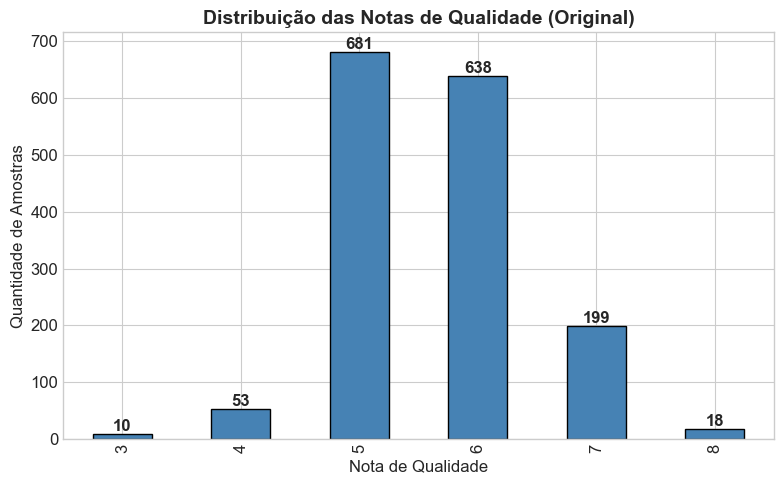

In [69]:
# Distribuição original da variável quality
print('=== Distribuição Original da Qualidade ===')
print(df['quality'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Distribuição das Notas de Qualidade (Original)', fontsize=14, fontweight='bold')
ax.set_xlabel('Nota de Qualidade')
ax.set_ylabel('Quantidade de Amostras')
for i, v in enumerate(df['quality'].value_counts().sort_index()):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/distribuicao_quality_original.png', dpi=150, bbox_inches='tight')
plt.show()

=== Distribuição da Classificação Binária ===
quality_label
0    1382
1     217
Name: count, dtype: int64

Baixa/Média Qualidade (0): 1382 (86.4%)
Alta Qualidade (1): 217 (13.6%)


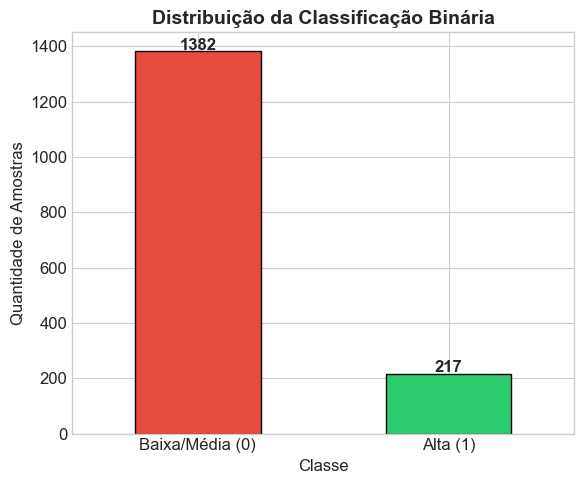

In [70]:
# Transformação em classificação binária
df['quality_label'] = (df['quality'] >= 7).astype(int)

print('=== Distribuição da Classificação Binária ===')
print(df['quality_label'].value_counts())
print()
print(f'Baixa/Média Qualidade (0): {(df["quality_label"]==0).sum()} ({(df["quality_label"]==0).mean()*100:.1f}%)')
print(f'Alta Qualidade (1): {(df["quality_label"]==1).sum()} ({(df["quality_label"]==1).mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#e74c3c', '#2ecc71']
df['quality_label'].value_counts().plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Distribuição da Classificação Binária', fontsize=14, fontweight='bold')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade de Amostras')
ax.set_xticklabels(['Baixa/Média (0)', 'Alta (1)'], rotation=0)
for i, v in enumerate(df['quality_label'].value_counts()):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/distribuicao_quality_binaria.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Distribuição das Variáveis

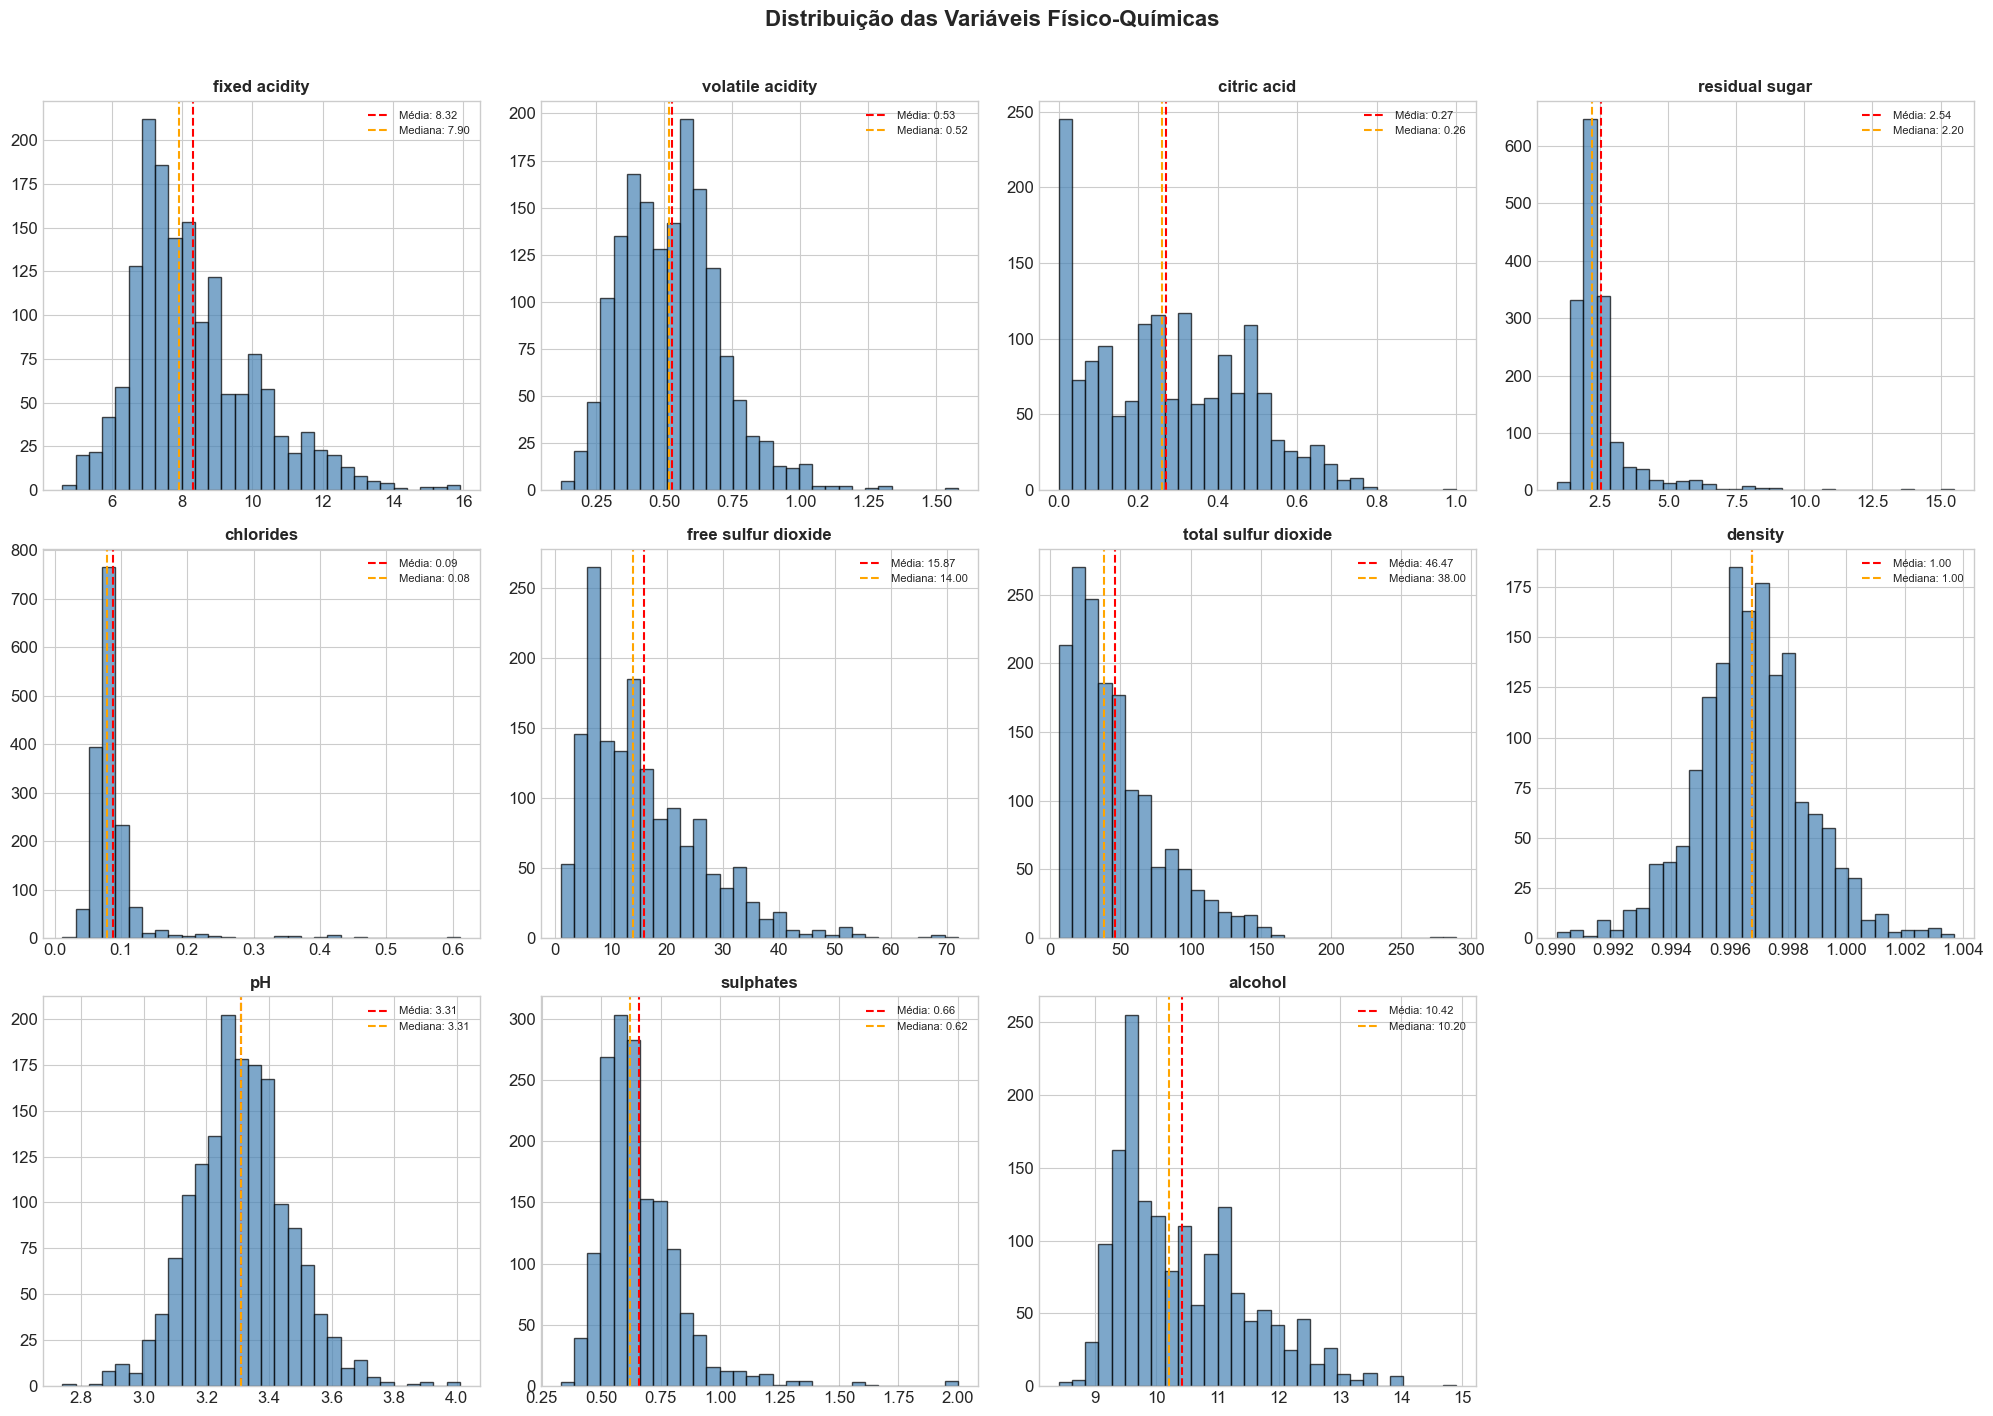

In [71]:
features = df.columns.drop(['quality', 'quality_label'])

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Média: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', label=f'Mediana: {df[col].median():.2f}')
    ax.legend(fontsize=8)

# Remove subplot vazio (se houver)
if len(features) < len(axes):
    axes[-1].set_visible(False)

fig.suptitle('Distribuição das Variáveis Físico-Químicas', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/distribuicao_variaveis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Distribuição das Variáveis por Classe de Qualidade

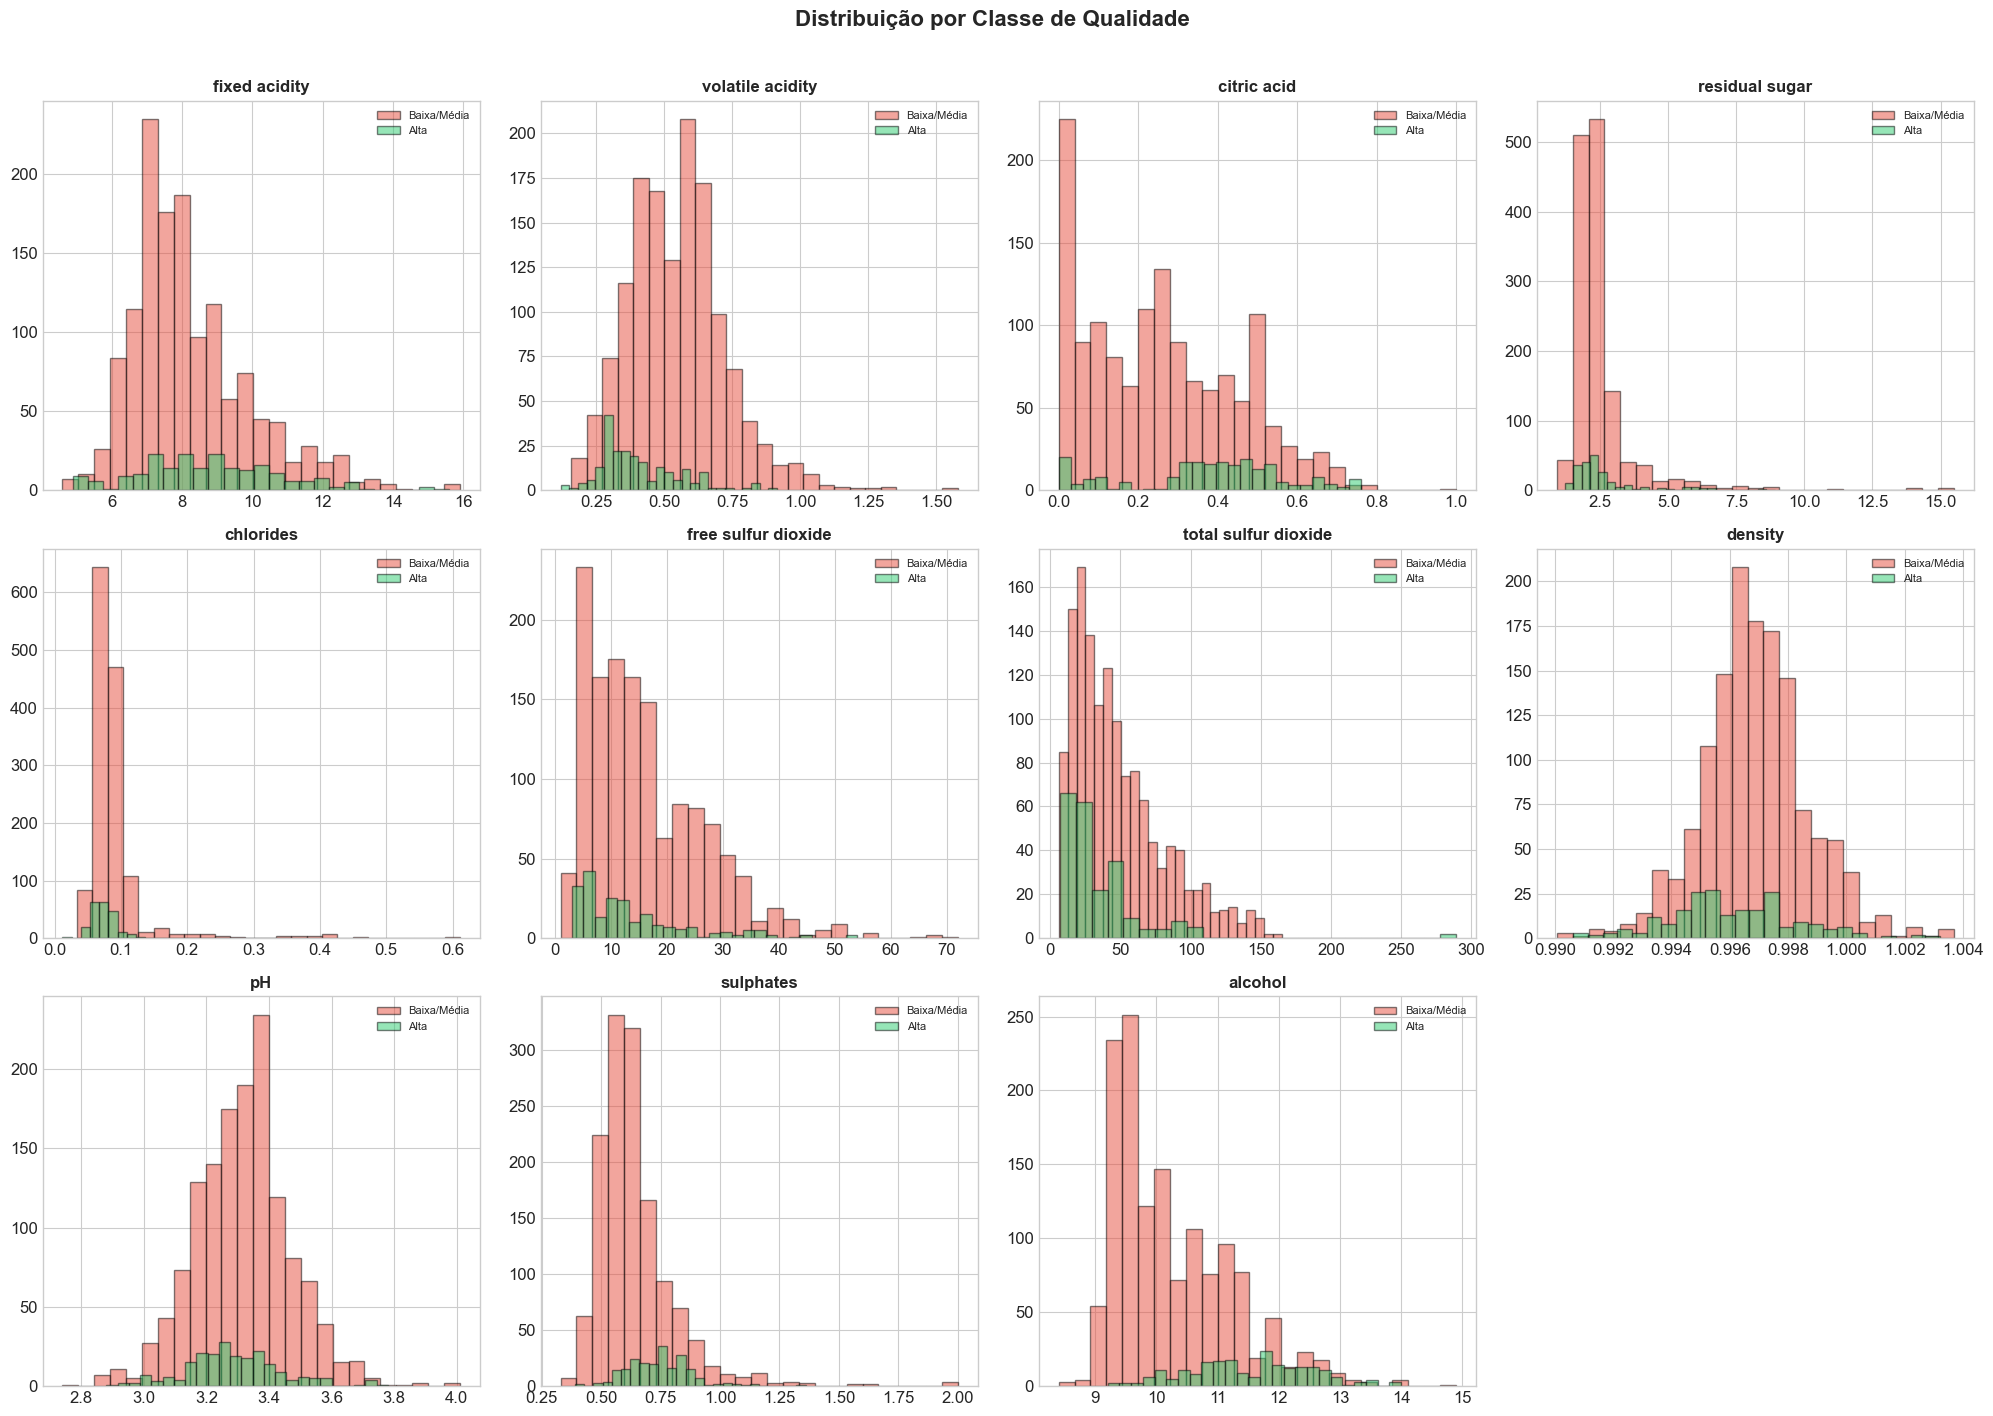

In [72]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    for label, color, name in [(0, '#e74c3c', 'Baixa/Média'), (1, '#2ecc71', 'Alta')]:
        subset = df[df['quality_label'] == label][col]
        ax.hist(subset, bins=25, alpha=0.5, color=color, edgecolor='black', label=name)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

if len(features) < len(axes):
    axes[-1].set_visible(False)

fig.suptitle('Distribuição por Classe de Qualidade', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/distribuicao_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Boxplots — Identificação de Outliers

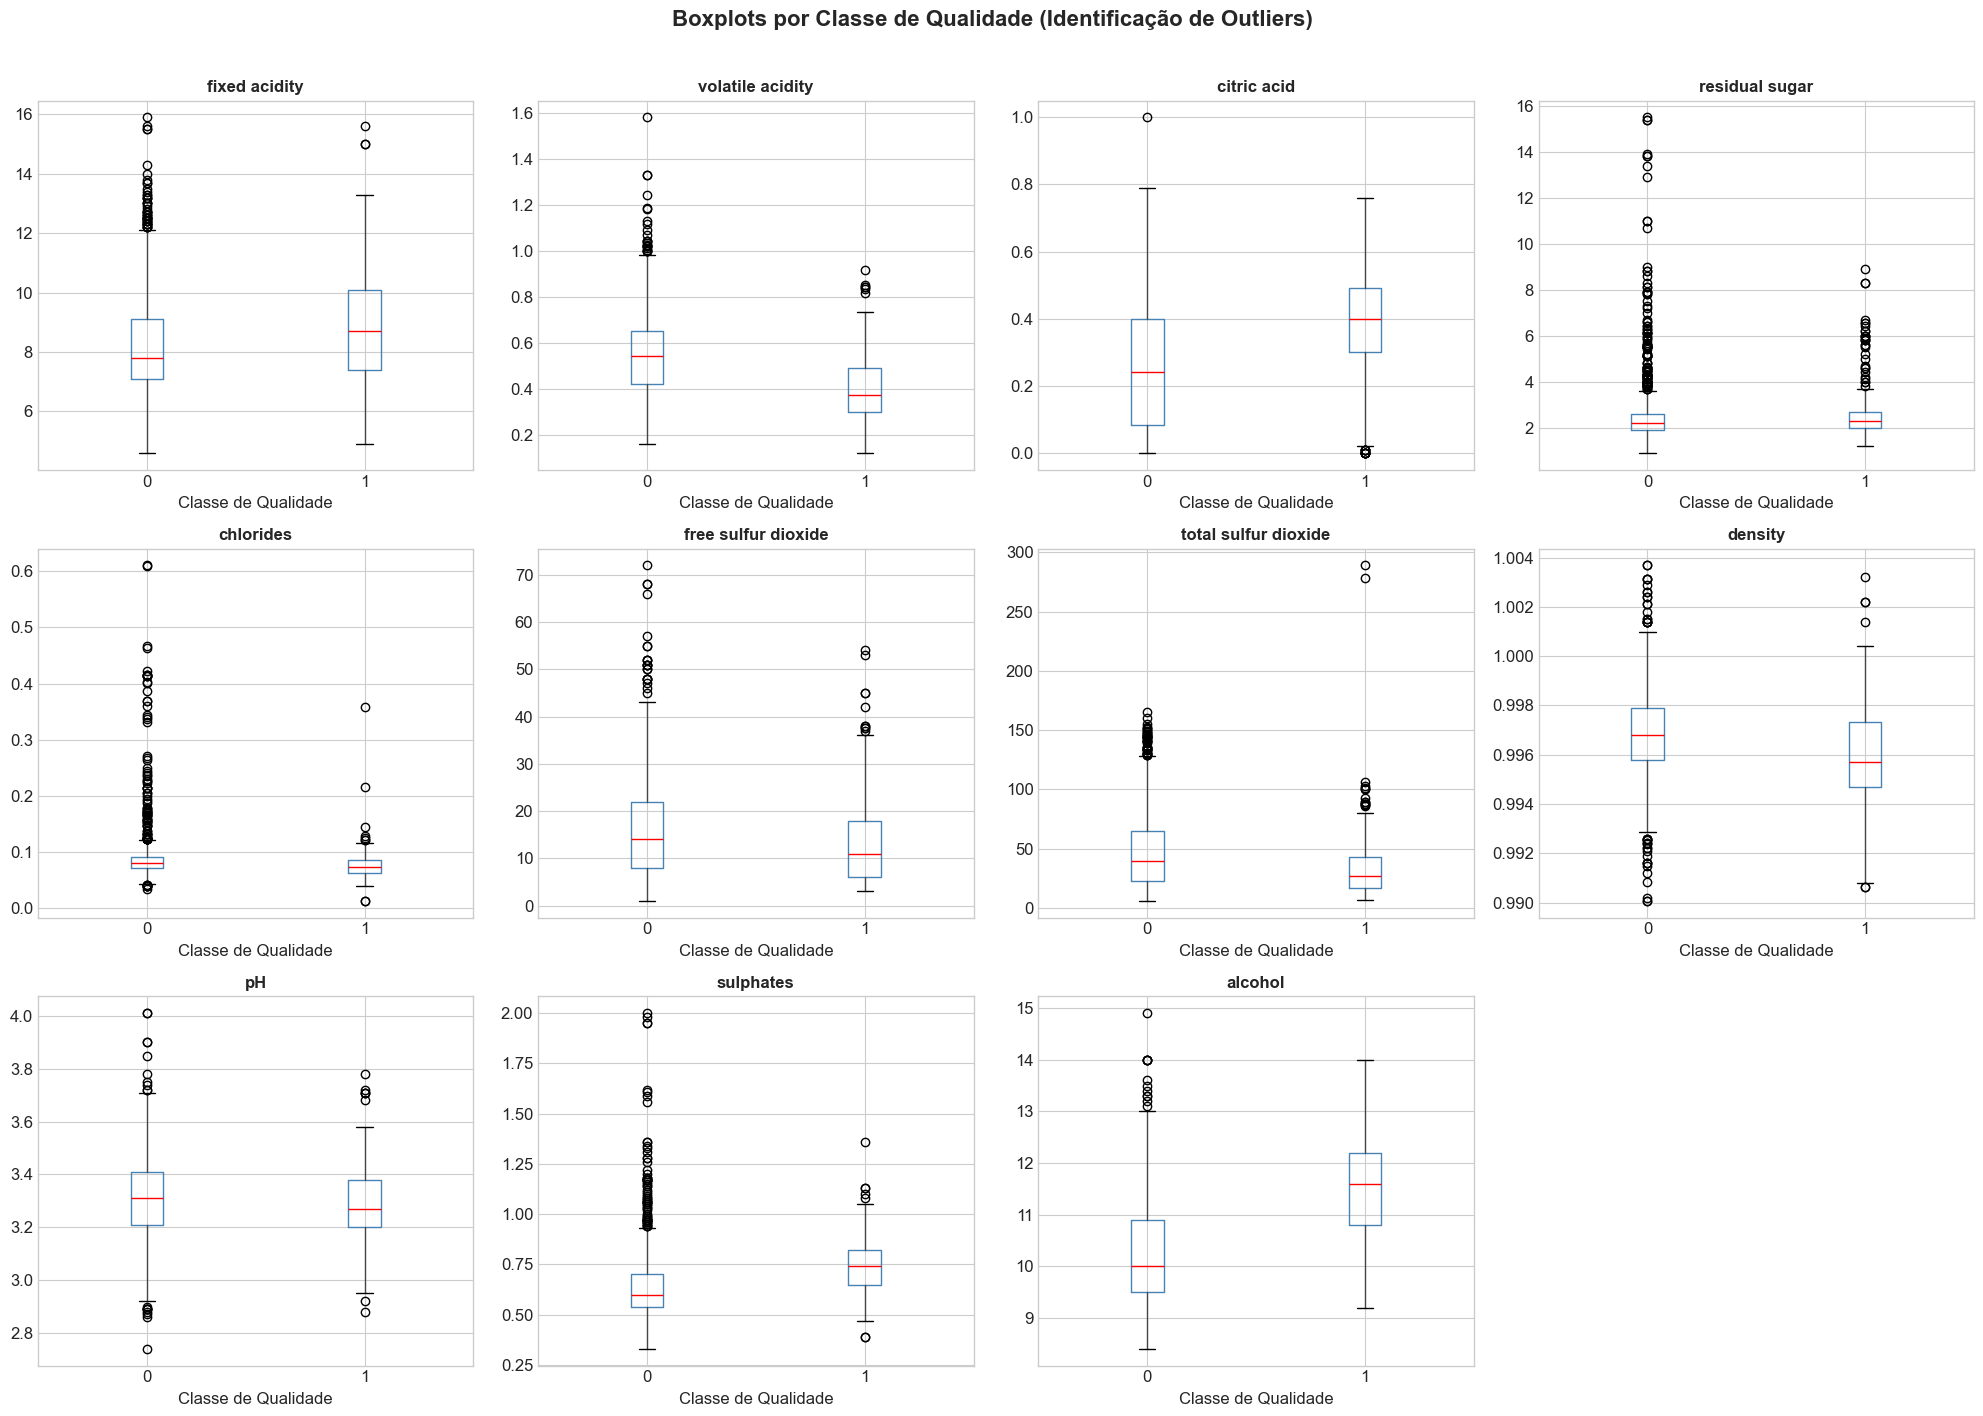

=== Quantidade de Outliers por Variável (Método IQR) ===
fixed acidity: 49 outliers (3.1%)
volatile acidity: 19 outliers (1.2%)
citric acid: 1 outliers (0.1%)
residual sugar: 155 outliers (9.7%)
chlorides: 112 outliers (7.0%)
free sulfur dioxide: 30 outliers (1.9%)
total sulfur dioxide: 55 outliers (3.4%)
density: 45 outliers (2.8%)
pH: 35 outliers (2.2%)
sulphates: 59 outliers (3.7%)
alcohol: 13 outliers (0.8%)


In [73]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    df.boxplot(column=col, by='quality_label', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Classe de Qualidade')

if len(features) < len(axes):
    axes[-1].set_visible(False)

fig.suptitle('Boxplots por Classe de Qualidade (Identificação de Outliers)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantificação de outliers por variável (método IQR)
print('=== Quantidade de Outliers por Variável (Método IQR) ===')
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'{col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)')

### 3.4 Matriz de Correlação

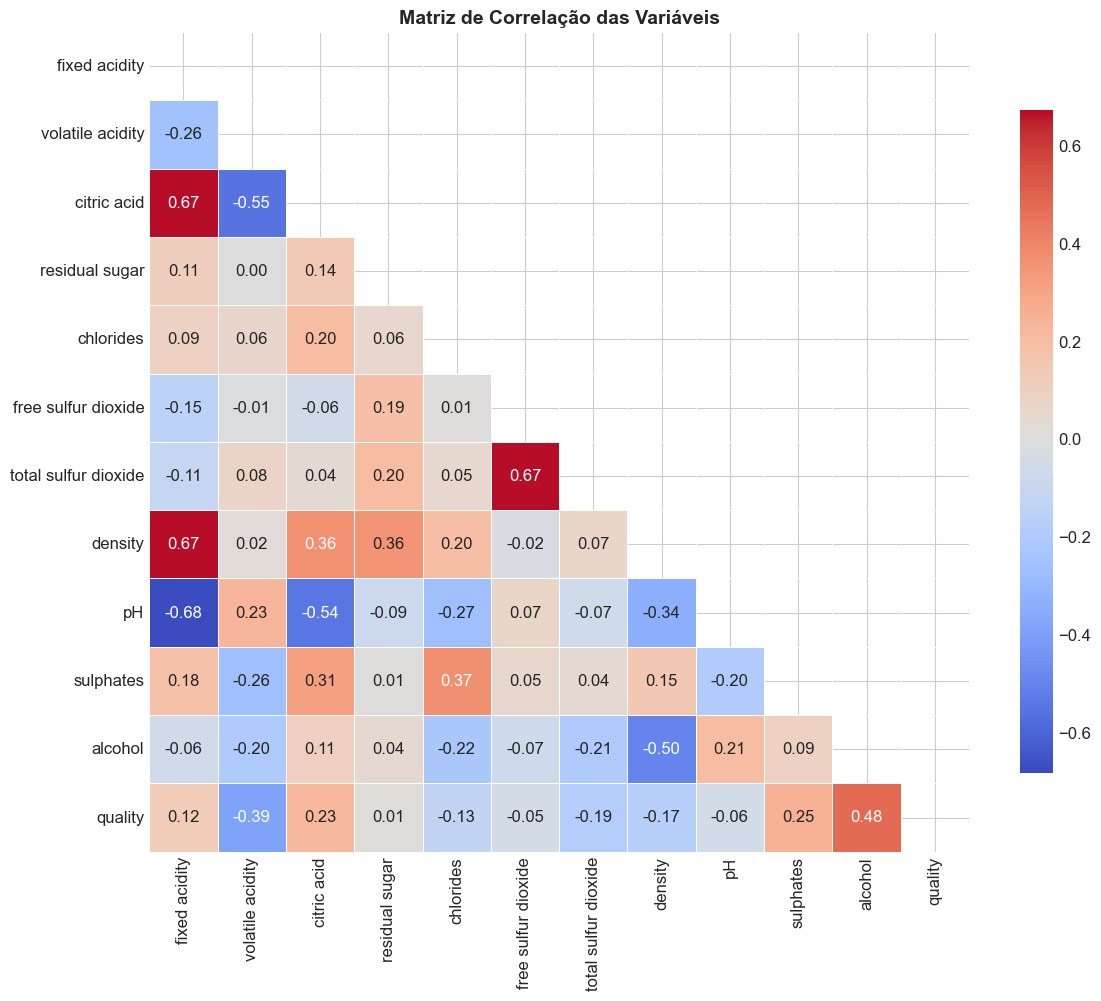

In [74]:
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df.drop(columns=['quality_label']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlação das Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

=== Correlação com a variável Quality ===
alcohol                 0.476
sulphates               0.251
citric acid             0.226
fixed acidity           0.124
residual sugar          0.014
free sulfur dioxide    -0.051
pH                     -0.058
chlorides              -0.129
density                -0.175
total sulfur dioxide   -0.185
volatile acidity       -0.391
Name: quality, dtype: float64


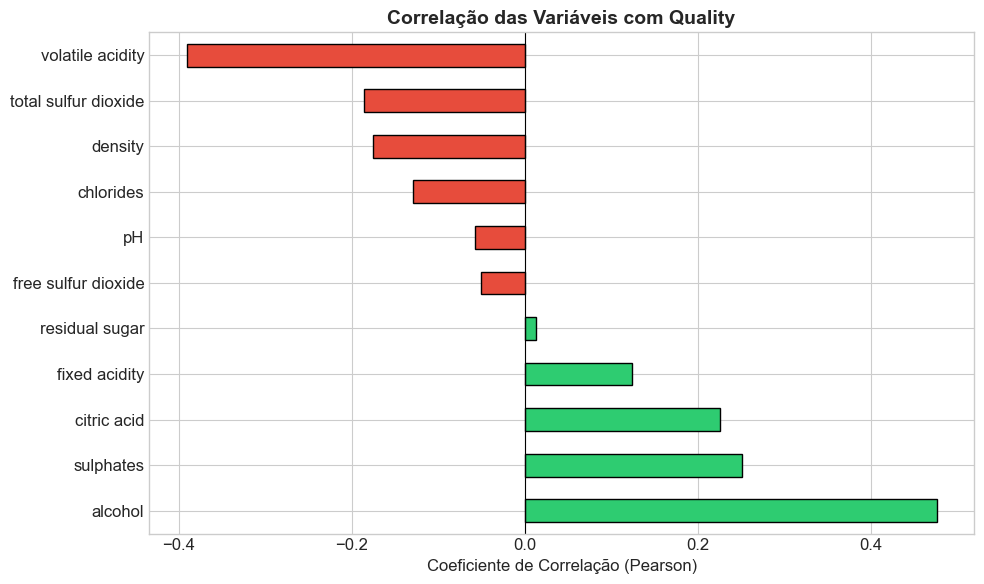

In [75]:
# Correlação das variáveis com quality
print('=== Correlação com a variável Quality ===')
corr_quality = df.drop(columns=['quality_label']).corr()['quality'].drop('quality').sort_values(ascending=False)
print(corr_quality.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_quality.values]
corr_quality.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
ax.set_title('Correlação das Variáveis com Quality', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlação (Pearson)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../results/correlacao_com_quality.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Análise e Justificativa das Correlações

**Correlações positivas com quality (variáveis que aumentam com a qualidade):**

- **Alcohol (~0.48):** Correlação positiva mais forte. Vinhos com maior teor alcoólico tendem a ser avaliados com notas mais altas. Isso reflete o fato de que uvas mais maduras produzem mais álcool e sabores mais complexos.

- **Sulphates (~0.25):** Correlação positiva moderada. Sulfatos contribuem para a preservação do vinho e podem realçar aromas, influenciando positivamente a percepção de qualidade.

- **Citric acid (~0.23):** Correlação positiva fraca. O ácido cítrico adiciona frescor e complexidade ao sabor, sendo desejável em quantidades moderadas.

**Correlações negativas com quality (variáveis que diminuem com a qualidade):**

- **Volatile acidity (~-0.39):** Correlação negativa significativa. Acidez volátil elevada indica presença de ácido acético (vinagre), resultando em sabor desagradável.

- **Total sulfur dioxide (~-0.19):** Correlação negativa fraca. Excesso de SO₂ pode causar aromas indesejados e mascarar características positivas do vinho.

- **Density (~-0.17):** Correlação negativa fraca. Vinhos menos densos geralmente têm maior teor alcoólico, o que se alinha com a correlação positiva do álcool.

**Correlações entre features (multicolinearidade):**

- **Fixed acidity × Citric acid:** Correlação positiva forte (~0.67) — ambos são ácidos presentes no vinho.
- **Fixed acidity × Density:** Correlação positiva forte (~0.67) — ácidos contribuem para a densidade.
- **Fixed acidity × pH:** Correlação negativa forte (~-0.68) — relação inversa natural entre acidez e pH.
- **Free sulfur dioxide × Total sulfur dioxide:** Correlação positiva (~0.67) — o SO₂ livre é componente do total.

### 3.6 Análise do Balanceamento das Classes

In [76]:
print('=== Balanceamento das Classes ===')
class_counts = df['quality_label'].value_counts()
class_pct = df['quality_label'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({
    'Classe': ['Baixa/Média Qualidade (0)', 'Alta Qualidade (1)'],
    'Quantidade': class_counts.values,
    'Percentual (%)': class_pct.values.round(1)
})
print(balance_df.to_string(index=False))

ratio = class_counts[0] / class_counts[1]
print(f'\nRazão de desbalanceamento: {ratio:.1f}:1')
print(f'\n⚠️  O dataset é DESBALANCEADO. A classe de alta qualidade é minoritária.')
print('Isso será tratado na etapa de modelagem (ex: class_weight, SMOTE, etc.).')

=== Balanceamento das Classes ===
                   Classe  Quantidade  Percentual (%)
Baixa/Média Qualidade (0)        1382            86.4
       Alta Qualidade (1)         217            13.6

Razão de desbalanceamento: 6.4:1

⚠️  O dataset é DESBALANCEADO. A classe de alta qualidade é minoritária.
Isso será tratado na etapa de modelagem (ex: class_weight, SMOTE, etc.).


---
## 4. Pré-processamento de Dados

### 4.1 Tratamento de Dados Faltantes

In [77]:
print('=== Verificação de Dados Faltantes ===')
print(f'Total de valores nulos: {df.isnull().sum().sum()}')
print('\n✅ Não há dados faltantes no dataset. Nenhum tratamento necessário.')

=== Verificação de Dados Faltantes ===
Total de valores nulos: 0

✅ Não há dados faltantes no dataset. Nenhum tratamento necessário.


### 4.2 Remoção de Duplicatas

In [78]:
print('=== Tratamento de Duplicatas ===')
duplicatas_antes = df.duplicated().sum()
print(f'Duplicatas encontradas: {duplicatas_antes}')

df = df.drop_duplicates()
print(f'Registros após remoção: {len(df)}')
print(f'Duplicatas removidas: {duplicatas_antes - df.duplicated().sum()}')

=== Tratamento de Duplicatas ===
Duplicatas encontradas: 240
Registros após remoção: 1359
Duplicatas removidas: 240


### 4.3 Separação de Features e Target

In [79]:
# Separação de features (X) e target (y)
X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

print(f'Features (X): {X.shape}')
print(f'Target (y): {y.shape}')
print(f'\nVariáveis utilizadas: {list(X.columns)}')

Features (X): (1359, 11)
Target (y): (1359,)

Variáveis utilizadas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


### 4.4 Divisão Treino/Teste

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nDistribuição no treino:')
print(f'  Classe 0: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)')
print(f'  Classe 1: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'\nDistribuição no teste:')
print(f'  Classe 0: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')
print(f'  Classe 1: {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')

Treino: 1087 amostras (80%)
Teste:  272 amostras (20%)

Distribuição no treino:
  Classe 0: 940 (86.5%)
  Classe 1: 147 (13.5%)

Distribuição no teste:
  Classe 0: 235 (86.4%)
  Classe 1: 37 (13.6%)


### 4.5 Normalização / Padronização (StandardScaler)

In [81]:
scaler = StandardScaler()

# Fit apenas no treino para evitar data leakage
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('=== Padronização Aplicada (StandardScaler) ===')
print('Fit realizado APENAS no conjunto de treino (evita data leakage).')
print(f'\nMédias no treino (devem ser ~0):')
print(X_train_scaled.mean().round(4).to_string())
print(f'\nDesvios-padrão no treino (devem ser ~1):')
print(X_train_scaled.std().round(4).to_string())

=== Padronização Aplicada (StandardScaler) ===
Fit realizado APENAS no conjunto de treino (evita data leakage).

Médias no treino (devem ser ~0):
fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar         -0.0
chlorides              -0.0
free sulfur dioxide     0.0
total sulfur dioxide   -0.0
density                -0.0
pH                      0.0
sulphates               0.0
alcohol                -0.0

Desvios-padrão no treino (devem ser ~1):
fixed acidity           1.0005
volatile acidity        1.0005
citric acid             1.0005
residual sugar          1.0005
chlorides               1.0005
free sulfur dioxide     1.0005
total sulfur dioxide    1.0005
density                 1.0005
pH                      1.0005
sulphates               1.0005
alcohol                 1.0005


### 4.6 Feature Engineering

In [82]:
# Criação de novas features baseadas em conhecimento do domínio
def create_features(df_input):
    df_feat = df_input.copy()
    
    # Razão entre acidez fixa e volátil — indica equilíbrio ácido
    df_feat['fixed_volatile_ratio'] = df_feat['fixed acidity'] / (df_feat['volatile acidity'] + 1e-6)
    
    # Razão entre SO2 livre e total — indica eficiência do SO2
    df_feat['free_total_so2_ratio'] = df_feat['free sulfur dioxide'] / (df_feat['total sulfur dioxide'] + 1e-6)
    
    # Acidez total (fixa + volátil + cítrica)
    df_feat['total_acidity'] = df_feat['fixed acidity'] + df_feat['volatile acidity'] + df_feat['citric acid']
    
    # Interação álcool × sulfatos — ambos correlacionados positivamente com qualidade
    df_feat['alcohol_sulphates'] = df_feat['alcohol'] * df_feat['sulphates']
    
    return df_feat

# Aplicar nos dados originais (não escalados) e depois escalar tudo junto
X_train_feat = create_features(X_train)
X_test_feat = create_features(X_test)

# Re-escalar com as novas features
scaler_feat = StandardScaler()
X_train_feat_scaled = pd.DataFrame(
    scaler_feat.fit_transform(X_train_feat),
    columns=X_train_feat.columns,
    index=X_train_feat.index
)
X_test_feat_scaled = pd.DataFrame(
    scaler_feat.transform(X_test_feat),
    columns=X_test_feat.columns,
    index=X_test_feat.index
)

print('=== Features Criadas ===')
new_features = ['fixed_volatile_ratio', 'free_total_so2_ratio', 'total_acidity', 'alcohol_sulphates']
for feat in new_features:
    print(f'  • {feat}')
print(f'\nTotal de features: {X_train_feat_scaled.shape[1]} (originais: {X_train_scaled.shape[1]} + novas: {len(new_features)})')

=== Features Criadas ===
  • fixed_volatile_ratio
  • free_total_so2_ratio
  • total_acidity
  • alcohol_sulphates

Total de features: 15 (originais: 11 + novas: 4)


### 4.7 Tratamento do Desbalanceamento (SMOTE)

In [83]:
# Instalar imblearn se necessário
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE

print('=== Antes do SMOTE ===')
print(f'Classe 0: {(y_train==0).sum()}')
print(f'Classe 1: {(y_train==1).sum()}')

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_feat_scaled, y_train)

print(f'\n=== Após SMOTE ===')
print(f'Classe 0: {(y_train_smote==0).sum()}')
print(f'Classe 1: {(y_train_smote==1).sum()}')
print(f'\n✅ Classes balanceadas com SMOTE (oversampling sintético da classe minoritária).')
print('O SMOTE foi aplicado APENAS no conjunto de treino.')

=== Antes do SMOTE ===
Classe 0: 940
Classe 1: 147

=== Após SMOTE ===
Classe 0: 940
Classe 1: 940

✅ Classes balanceadas com SMOTE (oversampling sintético da classe minoritária).
O SMOTE foi aplicado APENAS no conjunto de treino.


---
## 5. Desenvolvimento de Modelos

Vamos treinar **3 modelos** de classificação e comparar seus desempenhos:
1. **Regressão Logística** — modelo linear, simples e interpretável
2. **Random Forest** — ensemble baseado em árvores de decisão
3. **Gradient Boosting** — ensemble sequencial com boosting

### 5.1 Treinamento dos Modelos

In [84]:
# Definição dos modelos
models = {
    'Regressão Logística': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
}

# Treinamento
trained_models = {}
for name, model in models.items():
    print(f'Treinando {name}...')
    model.fit(X_train_smote, y_train_smote)
    trained_models[name] = model
    print(f'  ✅ {name} treinado com sucesso!')

print(f'\n🎯 {len(trained_models)} modelos treinados com dados balanceados (SMOTE).')

Treinando Regressão Logística...
  ✅ Regressão Logística treinado com sucesso!
Treinando Random Forest...
  ✅ Random Forest treinado com sucesso!
Treinando Gradient Boosting...
  ✅ Gradient Boosting treinado com sucesso!

🎯 3 modelos treinados com dados balanceados (SMOTE).


### 5.2 Validação Cruzada (Cross-Validation)

In [85]:
print('=== Validação Cruzada (5-Fold Stratified) ===')
print('Avaliação no conjunto de treino com SMOTE\n')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in trained_models.items():
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='f1')
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  F1-Score médio: {scores.mean():.4f} (± {scores.std():.4f})')
    print(f'  Scores: {[f"{s:.4f}" for s in scores]}\n')

=== Validação Cruzada (5-Fold Stratified) ===
Avaliação no conjunto de treino com SMOTE

Regressão Logística:
  F1-Score médio: 0.8282 (± 0.0209)
  Scores: ['0.8142', '0.8497', '0.8346', '0.7949', '0.8474']

Random Forest:
  F1-Score médio: 0.9171 (± 0.0145)
  Scores: ['0.9027', '0.9282', '0.9357', '0.8980', '0.9207']

Gradient Boosting:
  F1-Score médio: 0.9323 (± 0.0075)
  Scores: ['0.9250', '0.9275', '0.9299', '0.9330', '0.9463']



---
## 6. Avaliação dos Modelos

### 6.1 Predições no Conjunto de Teste

In [86]:
# Predições e probabilidades
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test_feat_scaled)
    probabilities[name] = model.predict_proba(X_test_feat_scaled)[:, 1]

print('Predições realizadas para todos os modelos no conjunto de TESTE.')

Predições realizadas para todos os modelos no conjunto de TESTE.


### 6.2 Métricas de Avaliação

In [87]:
print('=' * 70)
print('MÉTRICAS DE AVALIAÇÃO — CONJUNTO DE TESTE')
print('=' * 70)

metrics_data = []

for name in trained_models:
    y_pred = predictions[name]
    y_prob = probabilities[name]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    metrics_data.append({
        'Modelo': name,
        'Acurácia': acc,
        'Precisão': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })
    
    print(f'\n--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['Baixa/Média', 'Alta']))

metrics_df = pd.DataFrame(metrics_data)
print('\n' + '=' * 70)
print('COMPARAÇÃO RESUMIDA')
print('=' * 70)
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))

MÉTRICAS DE AVALIAÇÃO — CONJUNTO DE TESTE

--- Regressão Logística ---
              precision    recall  f1-score   support

 Baixa/Média       0.97      0.77      0.86       235
        Alta       0.36      0.84      0.51        37

    accuracy                           0.78       272
   macro avg       0.67      0.80      0.68       272
weighted avg       0.89      0.78      0.81       272


--- Random Forest ---
              precision    recall  f1-score   support

 Baixa/Média       0.93      0.88      0.90       235
        Alta       0.43      0.57      0.49        37

    accuracy                           0.84       272
   macro avg       0.68      0.72      0.70       272
weighted avg       0.86      0.84      0.85       272


--- Gradient Boosting ---
              precision    recall  f1-score   support

 Baixa/Média       0.92      0.91      0.91       235
        Alta       0.45      0.49      0.47        37

    accuracy                           0.85       272
   macr

### 6.3 Matrizes de Confusão

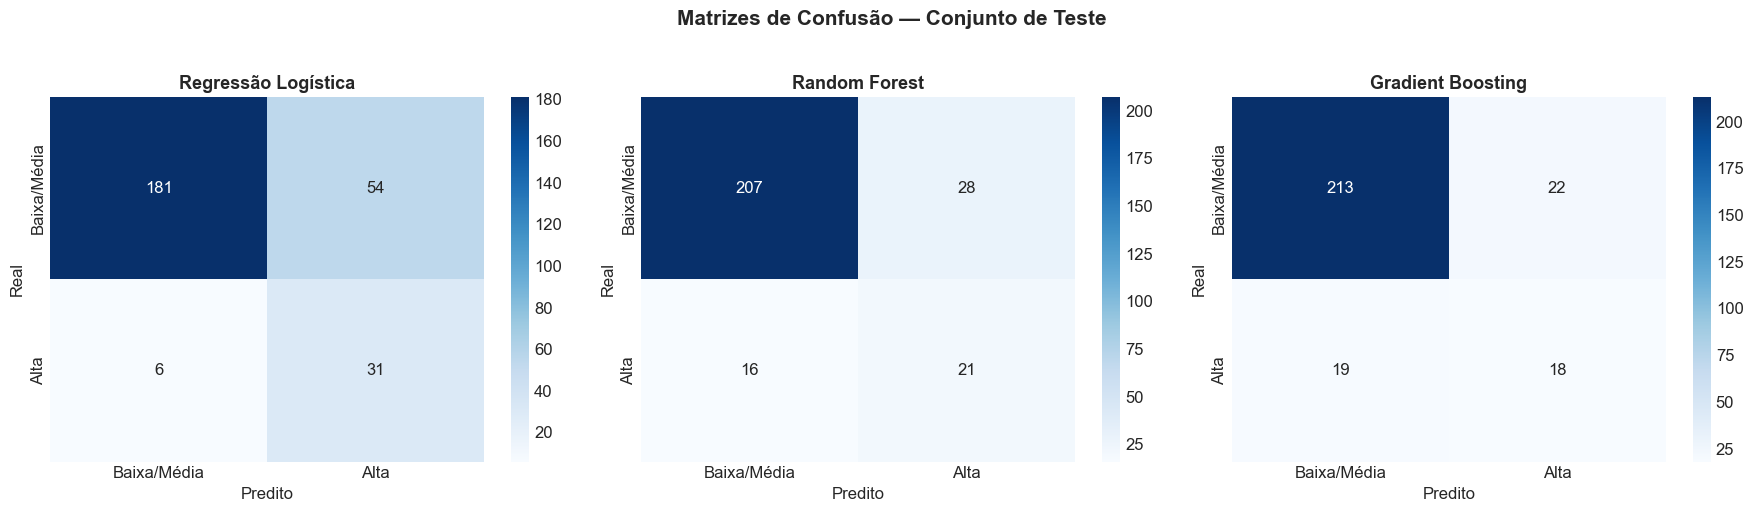

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Baixa/Média', 'Alta'],
                yticklabels=['Baixa/Média', 'Alta'])
    axes[i].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')

fig.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Curvas ROC

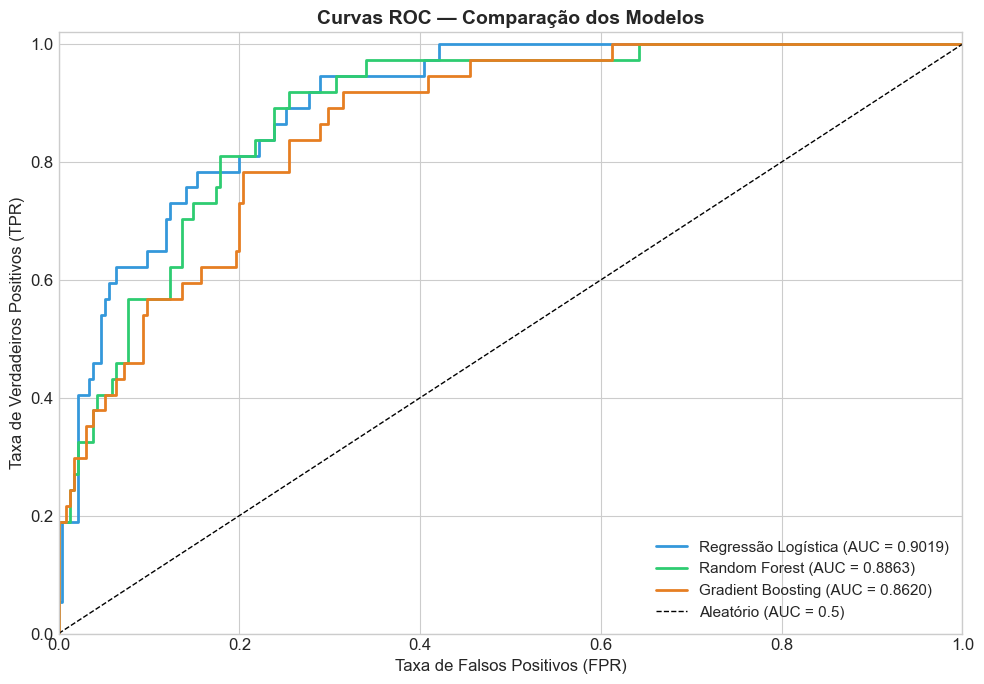

In [89]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#3498db', '#2ecc71', '#e67e22']

for i, (name, y_prob) in enumerate(probabilities.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.5)')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparação dos Modelos', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../results/curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Comparação Visual das Métricas

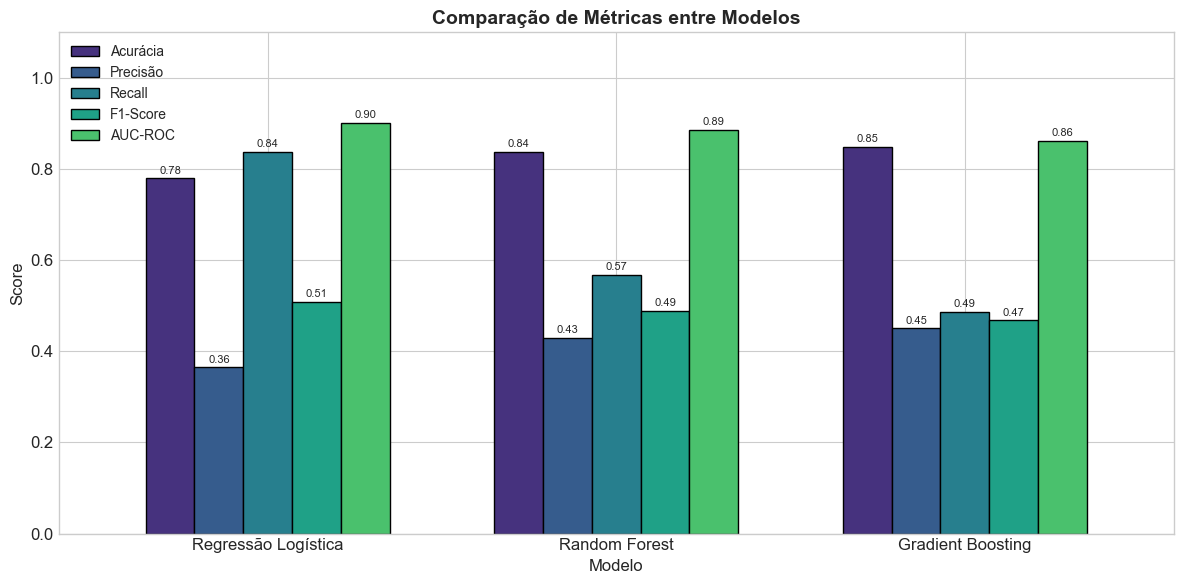

In [90]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics_plot = metrics_df.set_index('Modelo')
metrics_plot.plot(kind='bar', ax=ax, edgecolor='black', width=0.7)

ax.set_title('Comparação de Métricas entre Modelos', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim([0, 1.1])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper left', fontsize=10)

# Adicionar valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('../results/comparacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Interpretação dos Resultados

### 7.1 Importância das Variáveis (Feature Importance)

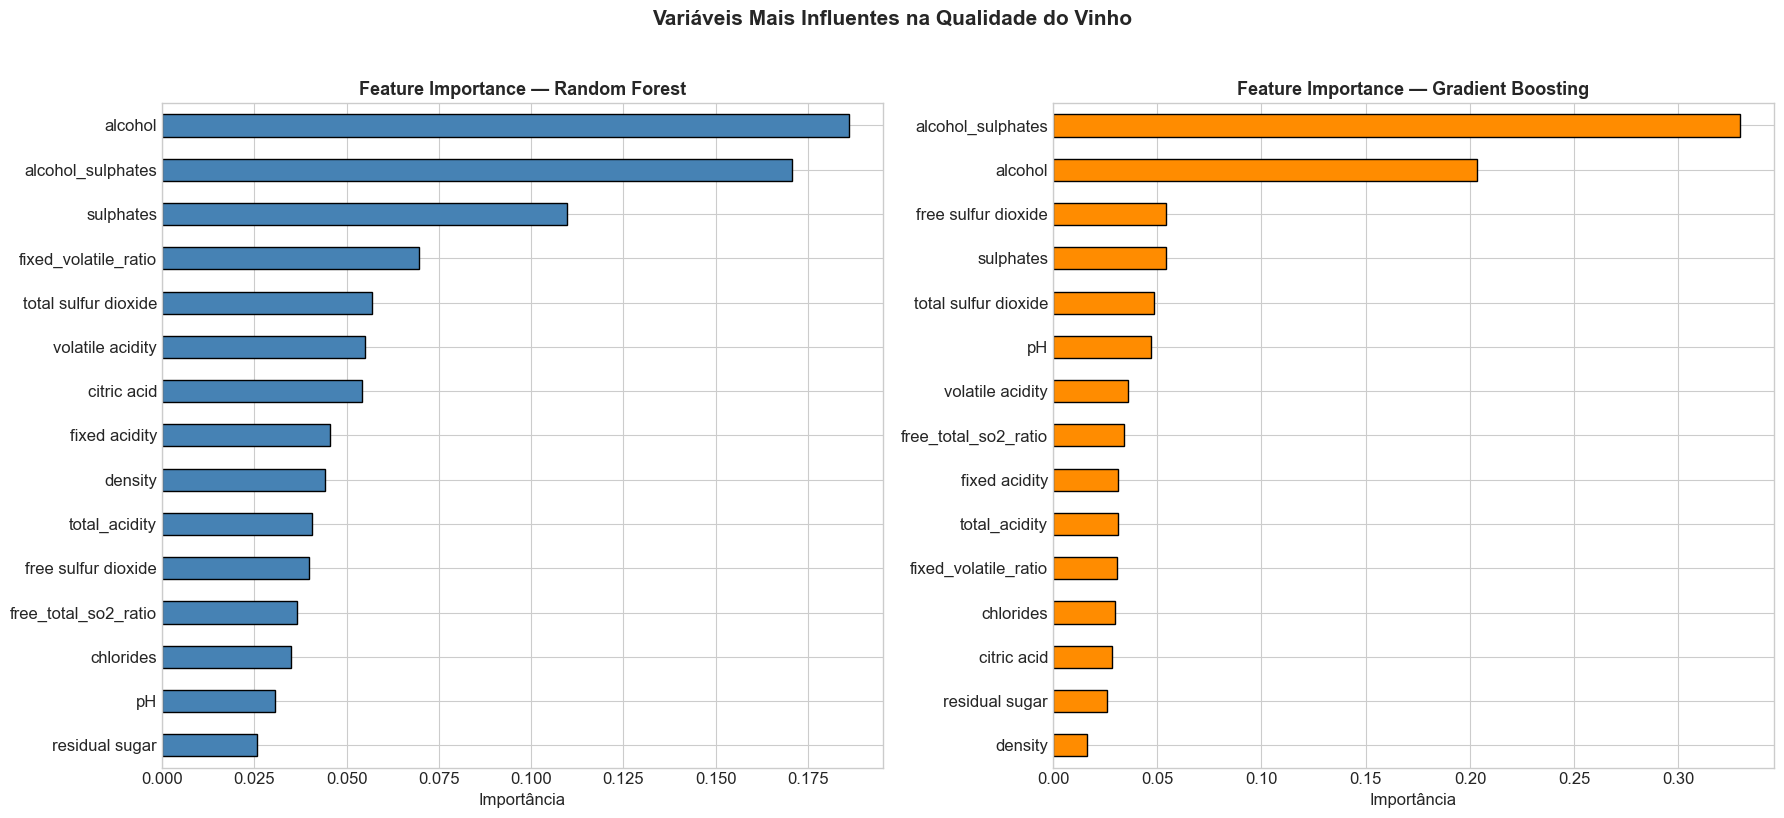

=== Top 5 Variáveis Mais Importantes ===

Random Forest:
  total sulfur dioxide: 0.0568
  fixed_volatile_ratio: 0.0696
  sulphates: 0.1096
  alcohol_sulphates: 0.1705
  alcohol: 0.1860

Gradient Boosting:
  total sulfur dioxide: 0.0485
  sulphates: 0.0540
  free sulfur dioxide: 0.0544
  alcohol: 0.2031
  alcohol_sulphates: 0.3293


In [91]:
# Feature importance do Random Forest
rf_model = trained_models['Random Forest']
feature_importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train_feat_scaled.columns
).sort_values(ascending=True)

# Feature importance do Gradient Boosting
gb_model = trained_models['Gradient Boosting']
feature_importance_gb = pd.Series(
    gb_model.feature_importances_,
    index=X_train_feat_scaled.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Random Forest
feature_importance_rf.plot(kind='barh', color='steelblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importância')

# Gradient Boosting
feature_importance_gb.plot(kind='barh', color='darkorange', edgecolor='black', ax=axes[1])
axes[1].set_title('Feature Importance — Gradient Boosting', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importância')

fig.suptitle('Variáveis Mais Influentes na Qualidade do Vinho', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Top 5 Variáveis Mais Importantes ===')
print('\nRandom Forest:')
for feat, imp in feature_importance_rf.tail(5).items():
    print(f'  {feat}: {imp:.4f}')
print('\nGradient Boosting:')
for feat, imp in feature_importance_gb.tail(5).items():
    print(f'  {feat}: {imp:.4f}')

### 7.2 Coeficientes da Regressão Logística

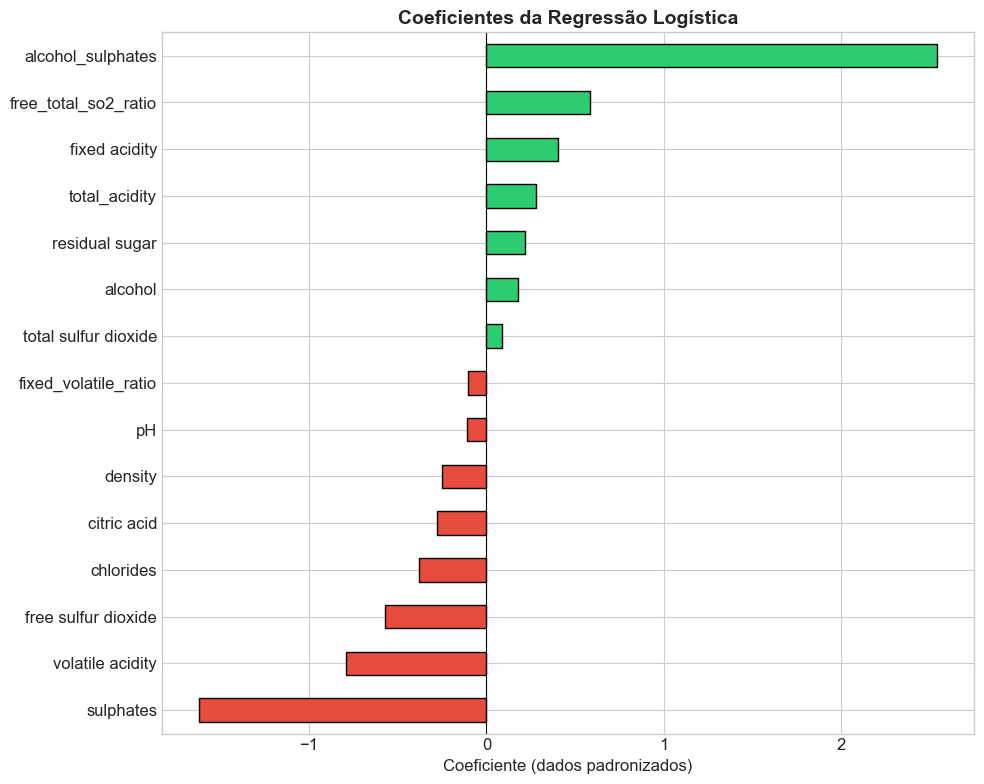

Coeficientes POSITIVOS → aumentam a probabilidade de Alta Qualidade
Coeficientes NEGATIVOS → diminuem a probabilidade de Alta Qualidade


In [92]:
lr_model = trained_models['Regressão Logística']
coef_df = pd.Series(
    lr_model.coef_[0],
    index=X_train_feat_scaled.columns
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_df.values]
coef_df.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
ax.set_title('Coeficientes da Regressão Logística', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente (dados padronizados)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../results/coeficientes_logistica.png', dpi=150, bbox_inches='tight')
plt.show()

print('Coeficientes POSITIVOS → aumentam a probabilidade de Alta Qualidade')
print('Coeficientes NEGATIVOS → diminuem a probabilidade de Alta Qualidade')

### 7.3 Discussão e Implicações para a Produção

Com base na análise dos modelos e das variáveis mais influentes, podemos extrair as seguintes conclusões e recomendações para o processo produtivo:

#### Variáveis mais influentes na qualidade:

1. **Teor Alcoólico (alcohol):** Consistentemente a variável mais importante em todos os modelos. Vinhos de alta qualidade tendem a ter maior teor alcoólico, o que está associado a uvas mais maduras e com maior concentração de açúcares. **Recomendação:** Investir em técnicas de cultivo que favoreçam a maturação completa das uvas.

2. **Acidez Volátil (volatile acidity):** Segunda variável mais relevante, com impacto **negativo** na qualidade. Níveis elevados indicam presença de ácido acético (vinagre). **Recomendação:** Monitorar rigorosamente a fermentação para evitar contaminação bacteriana e controlar a acidez volátil.

3. **Sulfatos (sulphates):** Contribuem positivamente para a qualidade, atuando como conservantes e realçando aromas. **Recomendação:** Otimizar a dosagem de sulfatos para preservar o vinho sem comprometer o sabor.

4. **Ácido Cítrico (citric acid):** Adiciona frescor e complexidade. **Recomendação:** Considerar ajustes na acidez cítrica durante a vinificação para melhorar o perfil sensorial.

5. **Dióxido de Enxofre Total (total sulfur dioxide):** Em excesso, impacta negativamente a qualidade. **Recomendação:** Controlar os níveis de SO₂ para manter a proteção antioxidante sem comprometer a qualidade.

#### Implicações práticas:

- **Controle de qualidade automatizado:** O modelo pode ser utilizado como ferramenta de triagem rápida durante a produção, identificando lotes com potencial de alta qualidade antes da avaliação sensorial.

- **Otimização do processo:** Os produtores podem focar nos parâmetros mais influentes (álcool, acidez volátil, sulfatos) para ajustar o processo produtivo e aumentar a proporção de vinhos de alta qualidade.

- **Redução de custos:** A previsão automatizada pode reduzir a dependência de painéis de degustação extensivos, reservando a avaliação humana para casos limítrofes.

### 7.4 Seleção do Melhor Modelo

In [93]:
print('=' * 70)
print('SELEÇÃO DO MELHOR MODELO')
print('=' * 70)

# Identificar o melhor modelo por F1-Score (métrica mais adequada para dados desbalanceados)
best_idx = metrics_df['F1-Score'].idxmax()
best_model_name = metrics_df.loc[best_idx, 'Modelo']
best_f1 = metrics_df.loc[best_idx, 'F1-Score']
best_auc = metrics_df.loc[best_idx, 'AUC-ROC']

print(f'\n🏆 Melhor modelo: {best_model_name}')
print(f'   F1-Score: {best_f1:.4f}')
print(f'   AUC-ROC:  {best_auc:.4f}')

print(f'\n📊 Justificativa:')
print(f'   O F1-Score foi escolhido como métrica principal por ser a média harmônica')
print(f'   entre Precisão e Recall, sendo especialmente adequado para datasets')
print(f'   desbalanceados como o nosso (86.4% vs 13.6%).')
print(f'\n   A AUC-ROC complementa a avaliação, medindo a capacidade do modelo')
print(f'   de discriminar entre as classes em diferentes thresholds.')

print(f'\n' + '=' * 70)
print('RESUMO FINAL')
print('=' * 70)
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))

SELEÇÃO DO MELHOR MODELO

🏆 Melhor modelo: Regressão Logística
   F1-Score: 0.5082
   AUC-ROC:  0.9019

📊 Justificativa:
   O F1-Score foi escolhido como métrica principal por ser a média harmônica
   entre Precisão e Recall, sendo especialmente adequado para datasets
   desbalanceados como o nosso (86.4% vs 13.6%).

   A AUC-ROC complementa a avaliação, medindo a capacidade do modelo
   de discriminar entre as classes em diferentes thresholds.

RESUMO FINAL
             Modelo  Acurácia  Precisão  Recall  F1-Score  AUC-ROC
Regressão Logística    0.7794    0.3647  0.8378    0.5082   0.9019
      Random Forest    0.8382    0.4286  0.5676    0.4884   0.8863
  Gradient Boosting    0.8493    0.4500  0.4865    0.4675   0.8620


---
## 8. Conclusão

Neste projeto, desenvolvemos uma pipeline completa de Machine Learning para classificar a qualidade de vinhos tintos com base em suas características físico-químicas.

**Principais etapas realizadas:**

1. **Compreensão do problema:** Transformamos a variável de qualidade (0-10) em classificação binária (Alta ≥ 7 vs Baixa/Média < 7).

2. **Análise Exploratória:** Identificamos que o dataset é desbalanceado (~86% classe majoritária), que o álcool tem a maior correlação positiva com qualidade, e que a acidez volátil tem a maior correlação negativa.

3. **Pré-processamento:** Removemos duplicatas, padronizamos as variáveis com StandardScaler, criamos 4 novas features via feature engineering, e aplicamos SMOTE para balancear as classes.

4. **Modelagem:** Treinamos 3 modelos (Regressão Logística, Random Forest e Gradient Boosting) e avaliamos com validação cruzada.

5. **Avaliação:** Comparamos os modelos usando Acurácia, Precisão, Recall, F1-Score e AUC-ROC, com visualizações de matrizes de confusão e curvas ROC.

6. **Interpretação:** Identificamos as variáveis mais influentes e discutimos implicações práticas para o processo de produção de vinhos.